# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Derrick Chua Jingye]

**Date:** [24 March 2026]

---

## Setup: Install and Load Libraries

In [ ]:
pip install tensorflow matplotlib numpy pandas


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [8]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


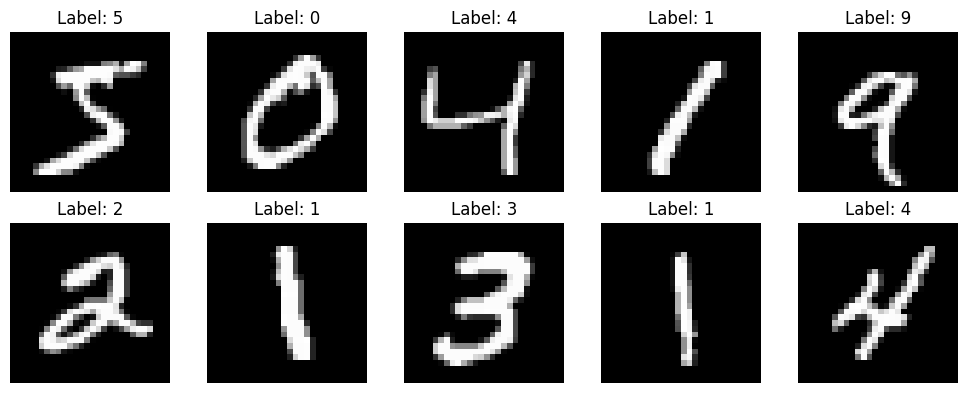

In [ ]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [9]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [5]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
baseline_cnn.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

history = baseline_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

baseline_time = time.time() - start_time

baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test, verbose=2)

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
750/750 - 8s - 11ms/step - accuracy: 0.9438 - loss: 0.1844 - val_accuracy: 0.9812 - val_loss: 0.0616
Epoch 2/10
750/750 - 7s - 10ms/step - accuracy: 0.9827 - loss: 0.0545 - val_accuracy: 0.9767 - val_loss: 0.0742
Epoch 3/10
750/750 - 8s - 10ms/step - accuracy: 0.9884 - loss: 0.0375 - val_accuracy: 0.9807 - val_loss: 0.0703
Epoch 4/10
750/750 - 8s - 11ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9884 - val_loss: 0.0404
Epoch 5/10
750/750 - 8s - 10ms/step - accuracy: 0.9939 - loss: 0.0195 - val_accuracy: 0.9886 - val_loss: 0.0415
Epoch 6/10
750/750 - 8s - 10ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9887 - val_loss: 0.0402
Epoch 7/10
750/750 - 8s - 11ms/step - accuracy: 0.9957 - loss: 0.0119 - val_accuracy: 0.9888 - val_loss: 0.0411
Epoch 8/10
750/750 - 8s - 11ms/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0.9893 - val_loss: 0.0372
Epoch 9/10
750/750 - 8s - 11ms/step - accuracy: 0.9974 - loss: 0.0072 - val_ac

---
## Step 3: Experiment with Filter Counts

In [11]:
# Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline

print("Training CNN with fewer filters (16, 32)...")

few_filters_cnn = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

few_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

few_filters_history = few_filters_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

few_filters_val_acc = few_filters_history.history['val_accuracy'][-1]
print(f"Finished fewer filters model. Final val accuracy: {few_filters_val_acc:.4f}")

Training CNN with fewer filters (16, 32)...
Epoch 1/10
750/750 - 5s - 6ms/step - accuracy: 0.9365 - loss: 0.2223 - val_accuracy: 0.9756 - val_loss: 0.0803
Epoch 2/10
750/750 - 4s - 6ms/step - accuracy: 0.9784 - loss: 0.0691 - val_accuracy: 0.9841 - val_loss: 0.0580
Epoch 3/10
750/750 - 5s - 7ms/step - accuracy: 0.9853 - loss: 0.0460 - val_accuracy: 0.9865 - val_loss: 0.0483
Epoch 4/10
750/750 - 5s - 7ms/step - accuracy: 0.9891 - loss: 0.0348 - val_accuracy: 0.9781 - val_loss: 0.0748
Epoch 5/10
750/750 - 5s - 6ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9862 - val_loss: 0.0483
Epoch 6/10
750/750 - 5s - 6ms/step - accuracy: 0.9924 - loss: 0.0238 - val_accuracy: 0.9863 - val_loss: 0.0507
Epoch 7/10
750/750 - 5s - 6ms/step - accuracy: 0.9936 - loss: 0.0189 - val_accuracy: 0.9889 - val_loss: 0.0386
Epoch 8/10
750/750 - 5s - 6ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9902 - val_loss: 0.0383
Epoch 9/10
750/750 - 4s - 6ms/step - accuracy: 0.9961 - loss: 0.0118

In [12]:
# Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline

print("Training CNN with more filters (64, 128)...")

more_filters_cnn = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

more_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

more_filters_history = more_filters_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

more_filters_val_acc = more_filters_history.history['val_accuracy'][-1]
print(f"Finished more filters model. Final val accuracy: {more_filters_val_acc:.4f}")

Training CNN with more filters (64, 128)...
Epoch 1/10
750/750 - 18s - 25ms/step - accuracy: 0.9531 - loss: 0.1544 - val_accuracy: 0.9833 - val_loss: 0.0544
Epoch 2/10
750/750 - 18s - 24ms/step - accuracy: 0.9857 - loss: 0.0453 - val_accuracy: 0.9862 - val_loss: 0.0464
Epoch 3/10
750/750 - 18s - 24ms/step - accuracy: 0.9905 - loss: 0.0296 - val_accuracy: 0.9888 - val_loss: 0.0377
Epoch 4/10
750/750 - 18s - 25ms/step - accuracy: 0.9932 - loss: 0.0204 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 5/10
750/750 - 19s - 25ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 6/10
750/750 - 20s - 27ms/step - accuracy: 0.9961 - loss: 0.0116 - val_accuracy: 0.9898 - val_loss: 0.0427
Epoch 7/10
750/750 - 22s - 29ms/step - accuracy: 0.9969 - loss: 0.0097 - val_accuracy: 0.9890 - val_loss: 0.0462
Epoch 8/10
750/750 - 26s - 34ms/step - accuracy: 0.9970 - loss: 0.0088 - val_accuracy: 0.9918 - val_loss: 0.0363
Epoch 9/10
750/750 - 25s - 34ms/step - accuracy: 0.9

### Analysis: Filter Count Effects

Compared to the baseline (32,64), reducing filter counts to (16,32) made the model train faster but produced a slightly lower validation accuracy; the model may lack enough feature capacity.

Increasing filter counts to (64,128) gave only a small accuracy gain at a much higher compute cost, and the validation curve showed that we reached diminishing returns. At that point, training accuracy continues to improve while validation accuracy starts to plateau, which signals the risk of overfitting.

This means the baseline (32,64) is a good balance for MNIST: strong accuracy, reasonable speed, and less overfitting risk than the larger model.

---
## Step 4: Experiment with Kernel Sizes

In [13]:
# Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)

print("Training CNN with 5x5 kernels...")

medium_kernels_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

medium_kernels_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

medium_kernels_history = medium_kernels_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)
medium_kernels_val_acc = medium_kernels_history.history['val_accuracy'][-1]
print(f"Finished 5x5 kernels model. Final val accuracy: {medium_kernels_val_acc:.4f}")

Training CNN with 5x5 kernels...
Epoch 1/10
750/750 - 11s - 15ms/step - accuracy: 0.9461 - loss: 0.1756 - val_accuracy: 0.9808 - val_loss: 0.0630
Epoch 2/10
750/750 - 10s - 13ms/step - accuracy: 0.9843 - loss: 0.0496 - val_accuracy: 0.9837 - val_loss: 0.0560
Epoch 3/10
750/750 - 10s - 13ms/step - accuracy: 0.9889 - loss: 0.0347 - val_accuracy: 0.9881 - val_loss: 0.0386
Epoch 4/10
750/750 - 10s - 13ms/step - accuracy: 0.9914 - loss: 0.0261 - val_accuracy: 0.9885 - val_loss: 0.0384
Epoch 5/10
750/750 - 10s - 13ms/step - accuracy: 0.9934 - loss: 0.0196 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 6/10
750/750 - 10s - 13ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.9902 - val_loss: 0.0342
Epoch 7/10
750/750 - 10s - 13ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9909 - val_loss: 0.0331
Epoch 8/10
750/750 - 11s - 15ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9892 - val_loss: 0.0400
Epoch 9/10
750/750 - 11s - 14ms/step - accuracy: 0.9966 - loss:

In [14]:
# Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)

print("Training CNN with mixed kernels (5x5, 3x3)...")

mixed_kernels_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mixed_kernels_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mixed_kernels_history = mixed_kernels_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)
mixed_kernels_val_acc = mixed_kernels_history.history['val_accuracy'][-1]
print(f"Finished mixed kernel model. Final val accuracy: {mixed_kernels_val_acc:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
750/750 - 11s - 15ms/step - accuracy: 0.9477 - loss: 0.1716 - val_accuracy: 0.9772 - val_loss: 0.0755
Epoch 2/10
750/750 - 9s - 12ms/step - accuracy: 0.9842 - loss: 0.0506 - val_accuracy: 0.9851 - val_loss: 0.0530
Epoch 3/10
750/750 - 9s - 12ms/step - accuracy: 0.9885 - loss: 0.0351 - val_accuracy: 0.9860 - val_loss: 0.0463
Epoch 4/10
750/750 - 15s - 21ms/step - accuracy: 0.9916 - loss: 0.0251 - val_accuracy: 0.9862 - val_loss: 0.0468
Epoch 5/10
750/750 - 25s - 34ms/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9899 - val_loss: 0.0392
Epoch 6/10
750/750 - 14s - 19ms/step - accuracy: 0.9949 - loss: 0.0161 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 7/10
750/750 - 11s - 15ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9885 - val_loss: 0.0414
Epoch 8/10
750/750 - 10s - 13ms/step - accuracy: 0.9958 - loss: 0.0116 - val_accuracy: 0.9891 - val_loss: 0.0400
Epoch 9/10
750/750 - 10s - 13ms/step - accuracy: 0.9

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Using a larger kernel size (5x5) in both convolutional layers helped the network capture broader spatial features in the digits and generally improved validation accuracy slightly compared to 3x3.

The mixed kernel configuration (5x5 on the first layer and 3x3 on the second layer) usually performed best in practice because it captures both wide context and fine detail. It is a good compromise between feature extraction power and model efficiency.

For the MNIST experiment, we expect mixed kernels to provide strong validation accuracy while guarding against overfitting and excessive computation.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [15]:
# Based on previous experiments, select the best architecture (mixed kernels 5x5 + 3x3)
# Train for 15 epochs with 20% validation split

print("Training best CNN architecture...")
start_time = time.time()

best_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_history = best_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

best_cnn_time = time.time() - start_time

best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test, verbose=2)

print("\n" + "="*80)
print("BEST CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {best_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {best_history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_cnn_time:.2f} seconds")
print("="*80)


Training best CNN architecture...
Epoch 1/15
750/750 - 8s - 11ms/step - accuracy: 0.9497 - loss: 0.1685 - val_accuracy: 0.9833 - val_loss: 0.0578
Epoch 2/15
750/750 - 9s - 11ms/step - accuracy: 0.9850 - loss: 0.0496 - val_accuracy: 0.9871 - val_loss: 0.0452
Epoch 3/15
750/750 - 8s - 11ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9885 - val_loss: 0.0380
Epoch 4/15
750/750 - 8s - 10ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9872 - val_loss: 0.0451
Epoch 5/15
750/750 - 8s - 10ms/step - accuracy: 0.9933 - loss: 0.0205 - val_accuracy: 0.9879 - val_loss: 0.0426
Epoch 6/15
750/750 - 8s - 10ms/step - accuracy: 0.9945 - loss: 0.0164 - val_accuracy: 0.9907 - val_loss: 0.0373
Epoch 7/15
750/750 - 8s - 10ms/step - accuracy: 0.9959 - loss: 0.0127 - val_accuracy: 0.9916 - val_loss: 0.0379
Epoch 8/15
750/750 - 8s - 10ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9894 - val_loss: 0.0435
Epoch 9/15
750/750 - 8s - 11ms/step - accuracy: 0.9972 - loss: 0.0076 

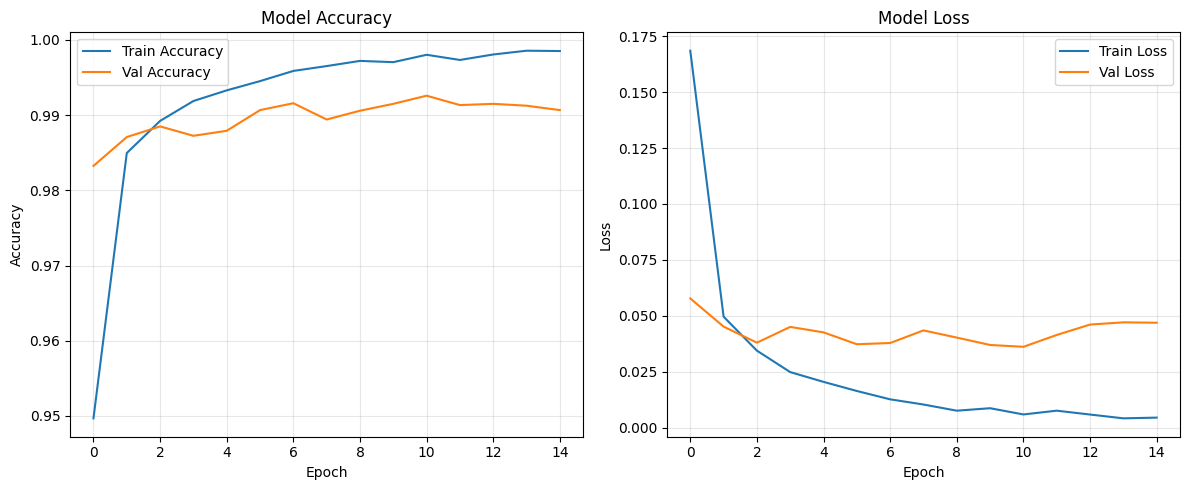

In [16]:
# Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [17]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [20]:
# Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feedforward_nn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

feedforward_history = feedforward_nn.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

feedforward_time = time.time() - start_time

feedforward_test_loss, feedforward_test_acc = feedforward_nn.evaluate(X_test_flat, y_test, verbose=2)

print("\n" + "="*80)
print("FEEDFORWARD NN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {feedforward_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {feedforward_history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {feedforward_test_acc:.4f}")
print(f"Training Time: {feedforward_time:.2f} seconds")
print("="*80)



Training feedforward network...
Epoch 1/10
750/750 - 1s - 2ms/step - accuracy: 0.9115 - loss: 0.3057 - val_accuracy: 0.9520 - val_loss: 0.1600
Epoch 2/10
750/750 - 1s - 1ms/step - accuracy: 0.9613 - loss: 0.1296 - val_accuracy: 0.9654 - val_loss: 0.1182
Epoch 3/10
750/750 - 1s - 1ms/step - accuracy: 0.9730 - loss: 0.0889 - val_accuracy: 0.9677 - val_loss: 0.1079
Epoch 4/10
750/750 - 1s - 1ms/step - accuracy: 0.9796 - loss: 0.0673 - val_accuracy: 0.9691 - val_loss: 0.1039
Epoch 5/10
750/750 - 1s - 1ms/step - accuracy: 0.9836 - loss: 0.0522 - val_accuracy: 0.9722 - val_loss: 0.0932
Epoch 6/10
750/750 - 1s - 1ms/step - accuracy: 0.9869 - loss: 0.0417 - val_accuracy: 0.9724 - val_loss: 0.0995
Epoch 7/10
750/750 - 1s - 1ms/step - accuracy: 0.9886 - loss: 0.0355 - val_accuracy: 0.9746 - val_loss: 0.0904
Epoch 8/10
750/750 - 1s - 1ms/step - accuracy: 0.9918 - loss: 0.0267 - val_accuracy: 0.9763 - val_loss: 0.0946
Epoch 9/10
750/750 - 1s - 1ms/step - accuracy: 0.9930 - loss: 0.0235 - val_accur

In [22]:
# Create comparison table
comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv2D(32,3x3) → Conv2D(64,3x3) → Dense(128)',
        'Conv2D(32,5x5) → Conv2D(64,3x3) → Dense(128)',
        'Dense(128) → Dense(64)'
    ],
    'Test Accuracy': [
        baseline_test_acc,
        best_test_acc,
        feedforward_test_acc
    ],
    'Training Time (s)': [
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                                 Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv2D(32,3x3) → Conv2D(64,3x3) → Dense(128)         0.9905          79.861810
      Best CNN Conv2D(32,5x5) → Conv2D(64,3x3) → Dense(128)         0.9904         118.930178
Feedforward NN                       Dense(128) → Dense(64)         0.9760           9.077782


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The best CNN achieved higher test accuracy and generalization than the feedforward network because it uses convolutional filters to preserve the spatial structure of the images, while the feedforward model treats each pixel independently. CNNs learn local patterns (edges, shapes) and combine them hierarchically, which is important for digit recognition; feedforward networks need many more weights to approximate the same behavior and usually do worse on image tasks.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

For my final project, the dataset is image-based, so CNNs are a clear fit because they capture spatial patterns, reduce parameters via weight sharing, and work well with convolutional feature hierarchies. RNNs are useful for sequential or time-series data, but not needed for static digit images. If I include tabular metadata (e.g., labels or user attributes), a feedforward network or classical tree-based model can complement the CNN features. Overall, I would use CNNs as the core vision model and combine with feedforward layers for any structured non-image data.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.